In [3]:
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    ElasticNet
)

from sklearn.tree      import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm       import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from sklearn.neural_network import MLPRegressor

# Para analise de dados e a avaliacao de modelos
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2, f_regression
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sktime.regression.interval_based import TimeSeriesForestRegressor

# RNA
import tensorflow as tf
import keras

In [4]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_model import ARIMA
import yfinance as yf

### Tolerancia do investidor ao risco e robos advisor

A tolerancia do investidor ao risco é uma das entradas mais importantes nos passos de alocação de portfolio e de rebalanceamento no processo de gestão de portfolio.

#### Definição do problema

Target: A verdadeira tolerancia ao risco de uma pessoa

variaveis preditoreas : são seus atributos demograficos, financeiros comportamentais.


In [5]:
dataset = pd.read_excel('dataset/SCFP2009panel.xlsx')

In [6]:
dataset_ = dataset

In [7]:
dataset.shape

(19285, 515)

Preparando a variavel prevista

1. Compute os ativos ariscados e sem risco para todos  os individuos nos dados da pesquisa.
    * Ativos arriscados 
        * Ações, títulos e fundos de investimentos
    * Ativos sem risco
        * Conta-corrente, poupança, certificados de depositos e outros saldos em caixa equivalente
2. Obtenha a proporção entre ativos arricadsos e o total de ativos de uma pessoa e considere isso como uma medida de sua tolerancia ao risco.
3. Identifique os investidores inteligente( é aquele que não altera sua tolerancia ao risco durante as mudanças de mercado).  Assim consideramos os investidores que tiveram uma alteração em sua tolerancia ao risco menor que 10% entre 2007 e 2009 com sendo inteligentes.

In [8]:
# Computar os ativos arriscados e não arriscados

dataset['RiskFree07'] = dataset['LIQ07'] + dataset['CDS07'] + dataset['SAVBND07'] + dataset['CASHLI07']
dataset['Risky07']    = dataset['NMMF07'] + dataset['STOCKS07'] + dataset['BOND07']

In [9]:
# ativos arricasoe  não arriscados em 2009
dataset['RiskFree09'] = dataset['LIQ09'] + dataset['CDS09'] + dataset['SAVBND09'] + dataset['CASHLI09']
dataset['Risky09']    = dataset['NMMF09'] + dataset['STOCKS09'] + dataset['BOND09']

In [10]:
# tolerancia ao risco para 2007
dataset['RiskTol07'] = dataset['Risky07'] / (dataset['Risky07'] + dataset['RiskFree07'])

In [11]:
# indice medio para ações normalizadas dos ativos arriscados
AVG_SP500_2007 = 1478
AVG_SP500_2009 = 948

dataset['RT09'] = (dataset['Risky09']) / ((dataset['Risky09'] + dataset['RiskFree09']) * (AVG_SP500_2007 / AVG_SP500_2009))

In [12]:
dataset.head()

,YY1,Y1,WGT09,AGE07,AGECL07,EDUC07,EDCL07,MARRIED07,KIDS07,LIFECL07,...,TRANSFOTHINCPCT,PSAVINGPCT,LEVERAGEPCT,I,RiskFree07,Risky07,RiskFree09,Risky09,RiskTol07,RT09
0,1,11,11668.134198,47,3,12,2,1,0,2,...,0.0,93.125197,270.403054,57,7994.813847,0.0,16000,17000,0.0,0.330422
1,1,12,11823.456494,47,3,12,2,1,0,2,...,0.0,93.125197,249.593620,57,7994.813847,0.0,19000,18000,0.0,0.312036
2,1,13,11913.228354,47,3,12,2,1,0,2,...,0.0,93.125197,209.233358,57,7984.457871,0.0,13000,12000,0.0,0.307876
3,1,14,11929.394266,47,3,12,2,1,0,2,...,0.0,93.125197,209.273158,57,7984.457871,0.0,25000,13000,0.0,0.219429
4,1,15,11917.722907,47,3,12,2,1,0,2,...,0.0,93.125197,232.690767,57,7994.813847,0.0,17000,12000,0.0,0.265410


Calculando tolerancia ao risco

In [13]:
dataset['PercentageChange'] = np.abs(dataset['RT09'] / dataset['RiskTol07'] - 1)

In [14]:
dataset = dataset.dropna(axis=0)

In [15]:
dataset = dataset[~(dataset.isin([np.nan, np.inf, -np.inf]).any(axis=1))]

<Axes: xlabel='RiskTol07', ylabel='Count'>

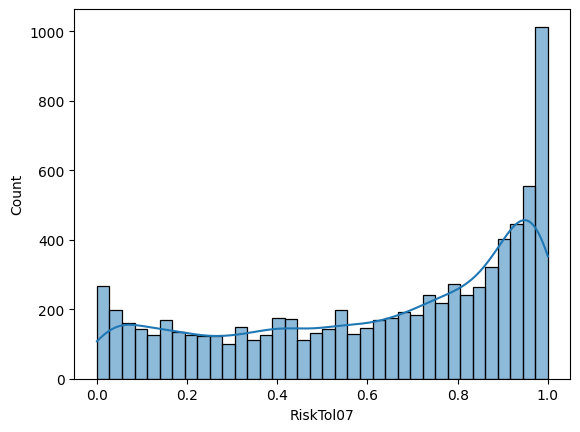

In [16]:
sns.histplot(dataset['RiskTol07'], bins=int(180/5), kde=True)

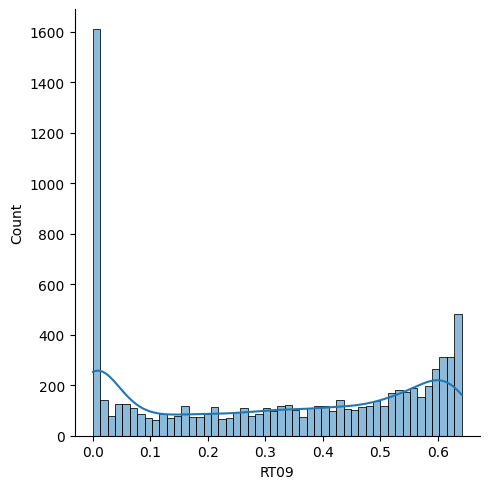

In [17]:
sns.displot(dataset['RT09'], bins=50, kde=True)

> Claramento o comportamento das pessoas foi revertido depois da crise. A torelancia geral ao risco diminiu , o que fica demonstrado pela proporção descomunal com tolerancia perto de zero em 2009.

In [45]:
# Pegando os 10% investidores inteligentes
dataset3 = dataset[dataset['PercentageChange'] <= 0.1]

In [46]:
# calculando a verdadeira tolerancia ao risco como a média ao risco desses investidores

dataset3.loc[:,'TrueRiskTol'] = (dataset3['RT09'] + dataset3['RiskTol07'])/2

C:\Users\mateu\AppData\Local\Temp\ipykernel_24112\4143533309.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset3.loc[:,'TrueRiskTol'] = (dataset3['RT09'] + dataset3['RiskTol07'])/2


In [47]:
dataset3 = dataset3.drop(columns=['RT09', 'PercentageChange', 'RiskTol07'])

Na literatura academica e a prática do setor indicam que a tolerancia ao risco é altamento influenciada pelos atributos demosgraficos, financeiros e comportamentos do inverstidor, como idade atual capital liguido e disposição em assumir risco.

* Atributos demograficos
    * idade, grau de intrução, estado civil e ocupação

* Financeiros
    * Gasto renda, patriminio liquido, renda

* disposição
    * disposição em assumir risco

In [48]:
with open('dataset/columns.txt', 'w') as f:
    for col in dataset3.columns:
        if '07' in col:
            f.write(col + '\n')


Nos dados existem mais de **500 features** no conjunto, mas a literatura acadêmica e a prática do setor indicam que a **tolerância ao risco** é altamente influenciada pelos seguintes atributos:  

* **Demográficos**  
* **Financeiros**  
* **Comportamentais do investidor**  

---

**AGE**  
* **Tipo:** Numérico (inteiro)  
* **Descrição:** Idade em anos.  
* **Exemplos:** 23, 45, 67.  
* **Notas:** Valores inválidos/ausentes: *NA* ou *99*.  

---

**EDUC**  
* **Tipo:** Categórica ordinal (inteiro)  
* **Descrição:** Grau de instrução.  
* **Códigos:**  
  * 1 = Ensino fundamental incompleto  
  * 2 = Ensino fundamental completo  
  * 3 = Ensino médio completo  
  * 4 = Ensino superior completo  
* **Notas:** Ajustar se o dataset usar categorias diferentes (ex.: *pós-graduação*).  

---

**MARRIED**  
* **Tipo:** Binária (inteiro)  
* **Descrição:** Estado civil (simplificado).  
* **Códigos:**  
  * 1 = Casado(a)  
  * 2 = Não casado(a) (*solteiro, separado, viúvo, etc.*)  
* **Notas:** Se houver categoria para *divorciado* ou *viúvo*, separar.  

---

**OCCU**  
* **Tipo:** Categórica (inteiro)  
* **Descrição:** Ocupação / classificação ocupacional.  
* **Códigos sugeridos:**  
  * 1 = Gerencial / cargos de gestão  
  * 2 = Profissional / técnico (*ex.: engenheiro, professor*)  
  * 3 = Operacional / serviços / comércio (*ex.: operário, vendedor*)  
  * 4 = Desempregado  
* **Notas:** Pode-se mapear mais detalhadamente se o dataset tiver códigos mais específicos.  

---

**KIDS**  
* **Tipo:** Numérico (inteiro)  
* **Descrição:** Número de filhos dependentes no domicílio.  
* **Exemplos:** 0, 1, 2, 3+ (pode usar *3 literal* ou flag alternativa).  
* **Notas:** Tratar *NA* e valores extremos.  

---

**WSAVED**  
* **Interpretação:** *Wealth saved* ou *willingness to save* — indicador de poupança / ativos líquidos.  
* **Tipo:** Binária (inteiro) ou contínua (se monetária).  

*Se binária (sugestão):*  
  * 0 = Não tem poupança / zero ativos líquidos  
  * 1 = Tem poupança / ativos líquidos > 0  

*Se contínua:* valor em moeda (*ex.: reais*).  
* **Notas:** Confirmar unidade (BRL?) e tratar outliers.  

---

**NWCAT**  
* **Interpretação:** *Net worth category* (patrimônio líquido).  
* **Tipo:** Categórica ordinal (inteiro).  
* **Códigos sugeridos:**  
  * 1 = Muito baixo  
  * 2 = Baixo  
  * 3 = Médio  
  * 4 = Alto  
  * 5 = Muito alto  
* **Notas:** Ajustar número de classes conforme dataset original.  

---

**INCCL**  
* **Interpretação:** *Income class* (classe de renda).  
* **Tipo:** Categórica ordinal (inteiro).  
* **Códigos sugeridos:**  
  * 1 = Muito baixa renda  
  * 2 = Baixa renda  
  * 3 = Renda média  
  * 4 = Alta renda  
  * 5 = Muito alta renda  
* **Notas:** Se houver valores monetários, converter para classes (quantis ou limites absolutos).  

---

**RISK**  
* **Interpretação:** Tolerância ao risco / aversão ao risco.  
* **Tipo:** Ordinal (inteiro).  
* **Códigos sugeridos (escala Likert 1–5):**  
  * 1 = Muito avesso ao risco  
  * 2 = Avesso ao risco  
  * 3 = Neutro / moderado  
  * 4 = Propenso ao risco  
  * 5 = Muito propenso ao risco  
* **Notas:** Se *RISK* for medido em percentuais ou *scores*, tratar como contínua.  


In [49]:
# 
columnas = [
    'AGE07',
    'EDCL07', # Grau de instrução
    'MARRIED07', # Estado civil 1: solteiro 2: casado
    'KIDS07', # Numero de filhos
    'OCCAT107', # Ocupação 1: sem ocupação 2: operário 3: técnico 4: profissional 5: gerente
    'INCOME07', # Renda anual  1 : inferior a $10mil 5: superior a $100mil
    'NETWORTH07', # Patrimonio liquido 1
    'RISK07', # Disposição em assumir risco 1: muito averso 5: muito disposto
    'TrueRiskTol'
]

drops = [col for col in dataset3.columns if col not in columnas]
dataset3 = dataset3.drop(columns=drops)

In [50]:
dataset['OCCAT107']

5        2
6        2
7        2
8        2
9        2
        ..
19275    1
19276    1
19277    1
19278    1
19279    1
Name: OCCAT107, Length: 7956, dtype: int64

In [51]:
dataset3.shape

(355, 9)

<Axes: >

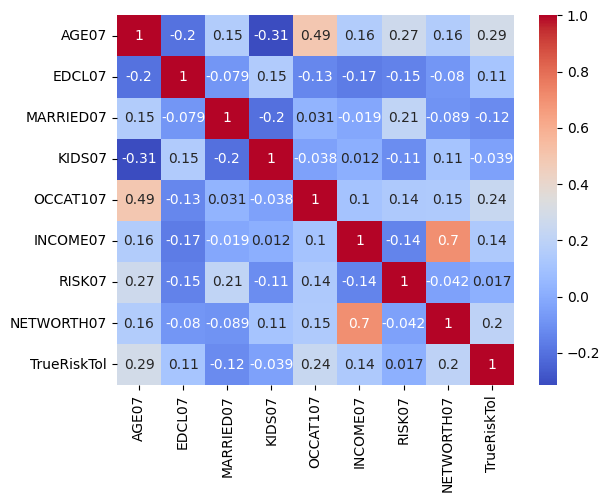

In [52]:
sns.heatmap(dataset3.corr(), annot=True, cmap='coolwarm')

In [53]:
dataset['NETWORTH07']

5        6.122453e+06
6        6.192874e+06
7        5.886337e+06
8        7.260575e+06
9        6.586401e+06
             ...     
19275    1.754199e+06
19276    1.650743e+06
19277    1.449837e+06
19278    1.617396e+06
19279    1.525539e+06
Name: NETWORTH07, Length: 7956, dtype: float64

Dividindo dados de treino e teste

In [54]:
y = dataset3['TrueRiskTol'].values.reshape(-1, 1)
X = dataset3.drop(columns=['TrueRiskTol']).values

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((284, 8), (71, 8), (284, 1), (71, 1))

In [56]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Lasso Regression', Lasso()),
    ('ElasticNet Regression', ElasticNet()),
    ('KNN Regressor', KNeighborsRegressor()),
    ('CART Regressor', DecisionTreeRegressor()),
    ('SVR Regressor', SVR()),
    ('Random Forest Regressor', RandomForestRegressor()),
    ('Gradient Boosting Regressor', GradientBoostingRegressor()),
    ('Extra Trees Regressor', ExtraTreesRegressor()),
    ('AdaBoost Regressor', AdaBoostRegressor()),
]

In [57]:
names = []
kfold_result = []
test_result = []
train_result = []

In [58]:
from concurrent.futures import ThreadPoolExecutor, wait, as_completed, FIRST_COMPLETED,ALL_COMPLETED

In [59]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=10)
    #converted mean square error to positive. The lower the beter
    cv_results = -1* cross_val_score(model, xtrain, ytrain.ravel(), cv=kfold, scoring='r2')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

Linear Regression: 0.087542 (0.694346)
Lasso Regression: 0.268309 (0.860589)
ElasticNet Regression: 0.216124 (0.821148)
KNN Regressor: -0.381466 (0.187300)
CART Regressor: -0.547508 (0.454084)
SVR Regressor: -0.133249 (0.103527)
Random Forest Regressor: -0.702538 (0.120288)
Gradient Boosting Regressor: -0.639548 (0.147368)
Extra Trees Regressor: -0.715098 (0.141963)
AdaBoost Regressor: -0.432456 (0.108492)


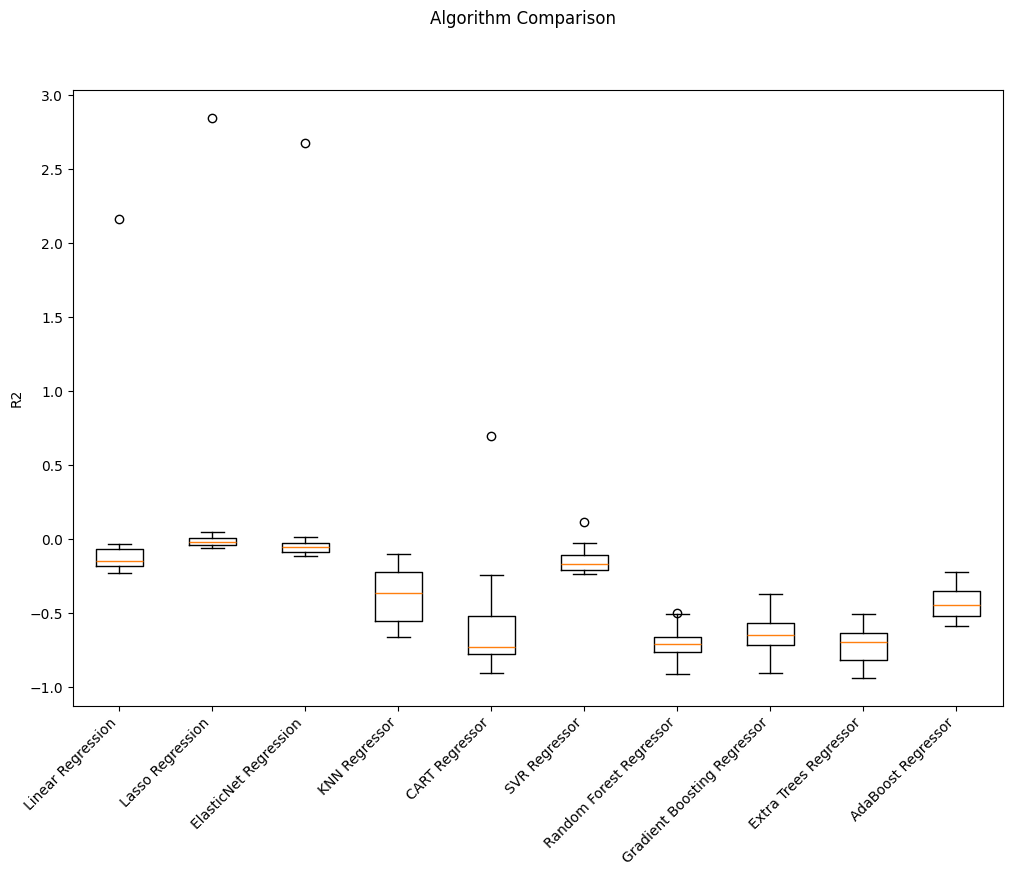

In [60]:
fig = plt.figure(figsize=(12,8))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=45, ha='right')
plt.ylabel('R2')
plt.show()

> Os modelos não lineares perfomam melhor que os modelos linear, oq significa que não há uma relação linear

Antes de treinar o random forests vamores testa um rede neural

In [61]:
model = keras.Sequential([
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation=keras.activations.selu, kernel_initializer=keras.initializers.lecun_normal()),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation=keras.activations.selu, kernel_initializer=keras.initializers.lecun_normal()),
    keras.layers.Dense(1)    
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error', 'r2_score']
)

history = model.fit(
    xtrain, ytrain,
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mean_absolute_error,r2_score
  current = self.get_monitor_value(logs)


In [62]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f'''
R2: {r2_score(ytest, model.predict(xtest)):.4f}
MAE: {mean_absolute_error(ytest, model.predict(xtest)):.4f}
MSE: {mean_squared_error(ytest, model.predict(xtest)):.4f}
''')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

R2: 0.4562
MAE: 0.1008
MSE: 0.0168



Agora o random forest

In [63]:
prams = {
    'n_estimators': [100, 200, 300],
    'min_samples_split': [2, 5, 10],
}

rf = RandomForestRegressor()

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=prams,
    scoring='r2',
    cv=5,
)
grid_search.fit(xtrain, ytrain.ravel())

,estimator,RandomForestRegressor()
,param_grid,"{'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [64]:
grid_search.best_params_, grid_search.best_score_

({'min_samples_split': 2, 'n_estimators': 100}, np.float64(0.7173840619413012))

In [65]:
random = grid_search.best_estimator_
random.fit(xtrain, ytrain.ravel())

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
pred = random.predict(xtest)

print(f'''
R2: {r2_score(ytest, pred):.4f}
MAE: {mean_absolute_error(ytest, pred):.4f}
MSE: {mean_squared_error(ytest, pred):.4f}
''')


R2: 0.6082
MAE: 0.0584
MSE: 0.0121



In [69]:
dataset3.drop(columns=['TrueRiskTol']).nunique()

AGE07          52
EDCL07          4
MARRIED07       2
KIDS07          6
OCCAT107        4
INCOME07      188
RISK07          4
NETWORTH07    288
dtype: int64

In [70]:
dataset3.describe()

,AGE07,EDCL07,MARRIED07,KIDS07,OCCAT107,INCOME07,RISK07,NETWORTH07,TrueRiskTol
count,355.000000,355.000000,355.000000,355.000000,355.000000,3.550000e+02,355.000000,3.550000e+02,355.000000
mean,53.047887,3.664789,1.200000,0.912676,1.630986,3.097267e+06,2.695775,2.010957e+07,0.402259
std,14.270806,0.734751,0.400565,1.284735,0.722244,1.383483e+07,0.779584,6.588316e+07,0.181977
min,20.000000,1.000000,1.000000,0.000000,1.000000,0.000000e+00,1.000000,-6.182000e+04,0.001832
25%,43.500000,4.000000,1.000000,0.000000,1.000000,7.987322e+04,2.000000,4.291517e+05,0.274706
50%,50.000000,4.000000,1.000000,0.000000,1.000000,2.204501e+05,3.000000,1.682121e+06,0.422015
75%,61.000000,4.000000,1.000000,2.000000,2.000000,7.188590e+05,3.000000,9.905492e+06,0.561649
max,89.000000,4.000000,2.000000,5.000000,4.000000,1.170707e+08,4.000000,9.301510e+08,0.671853


In [67]:
import pickle

with open('model_random_forest.pkl', 'wb') as f:
    pickle.dump(random, f)